# "Tipping points"

Many networks exhibit a "tipping point" property where a sharp phase transition occurs from local to global cascades as some parameter changes.

The parameters that we have examined which affect the nature of the cascade are:
* The standard deviation $\sigma$ of the threshold distribution function $f(\phi)$
* The size of the set of initially affected nodes $f^{IA}$ 

The value of the parameter which correlates with the tipping point in the cascade is referred to as the critical value.


In [2]:
import pickle
from utils import load_graph
import networkx as nx
import numpy as np
from models import threshold_norm_special, threshold
from heuristics import random_selection
import matplotlib.pyplot as plt

## Identifying $f^{IA}_c$ for a set of standard deviations

In the following, we try to identify the critical fraction of initially infected nodes for facebook_combined with:
* normally distributed $\phi$
* standard deviations $\sigma \in [0.0001 : 0.29]$
* constant $\langle\phi\rangle$ = 0.5

We do this by calculating the normalized variance of the distribution of activated nodes:

$\frac{\frac{1}{N}\textstyle\sum_{i=1}^Nn_i²}{(\frac{1}{N}\textstyle\sum_{i=1}^Nn_i)²}, N = simulations per combination, ni = activated nodes in simulation i$

### Run simulations

In [12]:
G : nx.Graph = load_graph("data/facebook_combined.txt")

Nn = len(G.nodes())

n_stds = 20                 # Number of standard deviations to test
n_fIAs = 18                 # Number of initial fractions to test
n_sims = int(Nn/10)       # Number of simulations to run per combination
total_sims = n_sims*n_fIAs*n_stds

l_std = 0.00001             # Lower bound of standard deviations
u_std = 0.29                # Upper bound of standard deviations

# Evenly spaced standard deviation values within range
# threshold_stds = np.linspace(l_std, u_std, n_stds)
threshold_stds = [0.2]

# Linear func to estimate the fIA bounds that we want for each std
a = (0.13 - 0.3) / (0.2 - 0.0001) # slope
b = 0.3 - a * 0.0001 # intercept
def fIA_center(std):
    return a * std + b

# Prep for simulations
results = {} # std : { fIA : [], Sus: [] }
print(f"Graph size: {Nn}")
print(f"Running {total_sims} simulations")
current_sim = 0

# Running simulations
for std in threshold_stds:
    curves = {
        "fIA" : [],
        "Sus" : []
    }

    # Estimating range where we are likely to find critical fraction
    center = fIA_center(std)
    left = max(0.05, center - 0.05)     # TODO: 0.1 was too much, 0.05 would probably do it and give more resolution in the curve
    right = min(0.5, center + 0.05)

    # Evenly spaced initial fraction values within range
    # fIAs = np.linspace(left, right, n_fIAs)
    fIAs = np.linspace(0.01, 0.2, 20)

    for fIA in fIAs:
        print(f"Running sims for std = {std}, fIA = {fIA}")
        S = []

        # Number of nodes in initially activates set
        seed_num = int(fIA * Nn)

        for i in range(n_sims):
            current_sim += 1
            if i % 50 == 0:
                print(f"{i} simulations done in permutation")
            
            # Select random seed nodes and run simulation
            seed = random_selection(G, seed_num)
            activated = threshold_norm_special(G, seed, 0.3, threshold_std=std)

            S.append(len(activated)/float(Nn))
        print(f"Simulations run: {current_sim} / {total_sims}")
        curves["fIA"].append(fIA)
        curves["Sus"].append(np.mean(np.array(S)**2)/np.mean(S)**2)
    results[std] = curves

# Pickle results
with open("fb_variance_mean_3_std_0.2.pkl", "wb") as f:
    pickle.dump(results, f)

Graph size: 4039
Running 145080 simulations
Running sims for std = 0.2, fIA = 0.01
0 simulations done in permutation
50 simulations done in permutation
100 simulations done in permutation
150 simulations done in permutation
200 simulations done in permutation
250 simulations done in permutation
300 simulations done in permutation
350 simulations done in permutation
400 simulations done in permutation
Simulations run: 403 / 145080
Running sims for std = 0.2, fIA = 0.02
0 simulations done in permutation
50 simulations done in permutation
100 simulations done in permutation
150 simulations done in permutation
200 simulations done in permutation
250 simulations done in permutation
300 simulations done in permutation
350 simulations done in permutation
400 simulations done in permutation
Simulations run: 806 / 145080
Running sims for std = 0.2, fIA = 0.03
0 simulations done in permutation
50 simulations done in permutation
100 simulations done in permutation
150 simulations done in permutat

KeyboardInterrupt: 

### Plot $f^{IA}$ curves

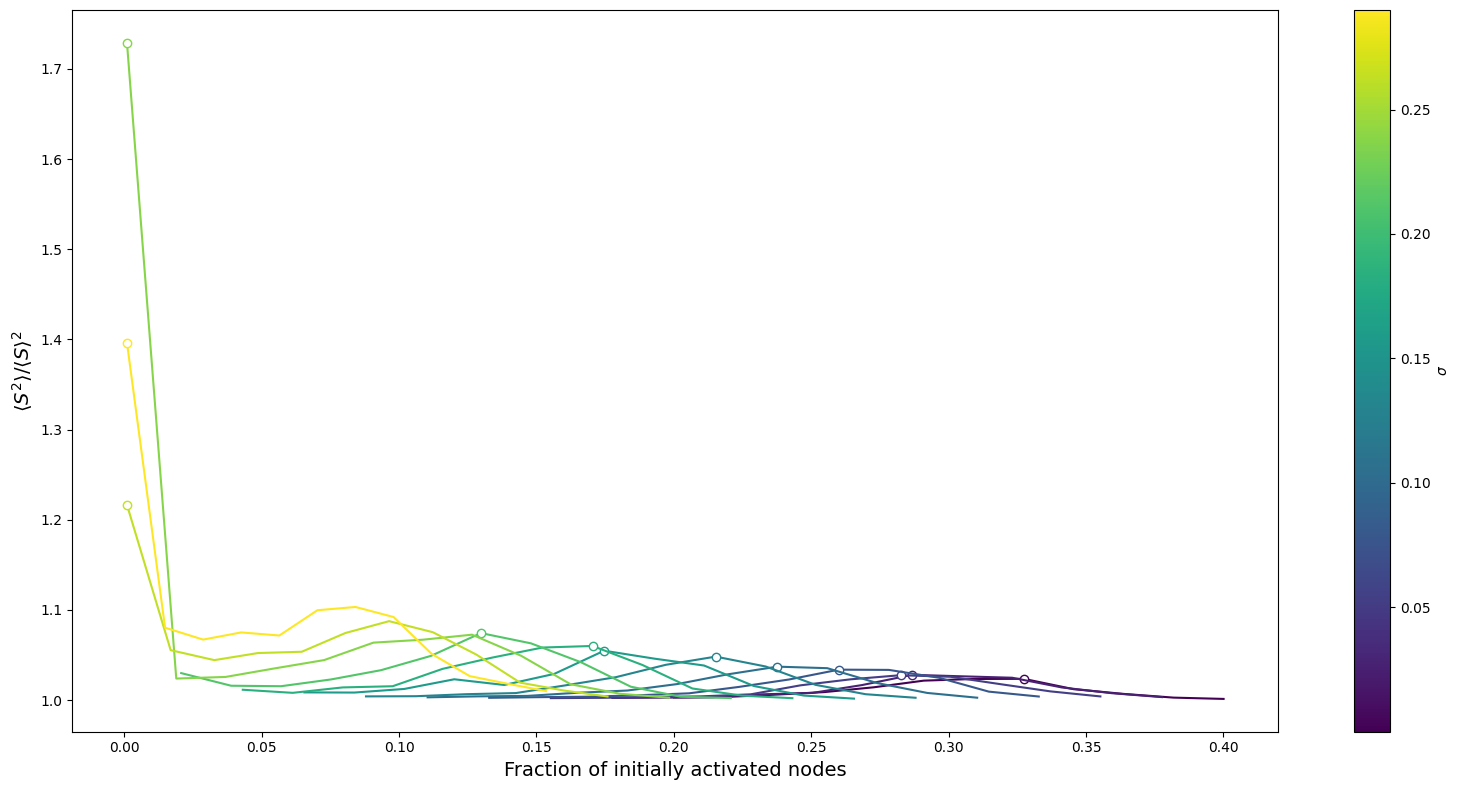

In [4]:
with open("fb_variance.pkl", 'rb') as f:
    data = pickle.load(f, encoding='latin1')

fig, ax = plt.subplots(figsize=(16,8))

stds = sorted(data.keys())
cmap = plt.cm.viridis
norm = plt.Normalize(min(stds), max(stds))

""" for std, curve in data.items():
    x = np.array(curve["fIA"])
    y = np.array(curve["Sus"])

    index = np.argmax(y)

    left = max(0, index - 5)
    right = min (len(x), index + 6)

    x_window = x[left:right]
    y_window = y[left:right]

    ax.plot(x_window, y_window,color=cmap(norm(std)), label=f"{std:.3f}")
    ax.plot(x[index],y[index],'-o',color=cmap(norm(std)),markerfacecolor='white') """

for std, curve in data.items():
    x = curve["fIA"]
    y = curve["Sus"]

    ax.plot(x,y, color=cmap(norm(std)))

    index = y.index(max(y))
    ax.plot(x[index],y[index],'-o',color=cmap(norm(std)),markerfacecolor='white')

#plt.legend(loc=0,frameon=False,ncol=2,fontsize=8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label=r"$\sigma$")

ax.set_ylabel(r'$\langle S^2 \rangle / \langle S \rangle^2$', fontsize=14)
ax.set_xlabel('Fraction of initially activated nodes', fontsize=14)

plt.tight_layout()
plt.show()

